In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0329.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0139.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0572_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0547_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0733.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0629_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0618_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0100.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenz

In [2]:
# ============================================================================
# CELL 1: Install and Import Dependencies
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {gpus}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# CELL 2: Load TBX11K Dataset (Binary: Normal vs TB, Already Balanced)

data_dir = '/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen'  # Adjust path

def load_tbx11k_binary(data_dir):
    """
    Load dataset containing 'Normal/' and 'TB/' folders.
    Dataset is already balanced -> no sampling.
    Returns: paths, labels (0 = Normal, 1 = TB)
    """

    tb_paths = []
    normal_paths = []

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        # Using your class folder names:
        if class_name.lower() == 'tb':
            tb_paths = [os.path.join(class_path, f) for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        elif class_name.lower() == 'normal':
            normal_paths = [os.path.join(class_path, f) for f in os.listdir(class_path)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Labels (no balancing needed)
    normal_labels = [0] * len(normal_paths)
    tb_labels = [1] * len(tb_paths)

    # Combine
    all_paths = np.array(normal_paths + tb_paths)
    all_labels = np.array(normal_labels + tb_labels)

    return all_paths, all_labels


# Load dataset (without balancing)
image_paths, labels = load_tbx11k_binary(data_dir)

print(f"\n✅ Dataset Loaded (Already Balanced):")
print(f"Total images: {len(image_paths)}")
print(f"Normal: {np.sum(labels == 0)}")
print(f"TB: {np.sum(labels == 1)}")



✅ Dataset Loaded (Already Balanced):
Total images: 2388
Normal: 1194
TB: 1194


In [4]:
# CELL 3: Train-Val-Test Split (70-15-15)
# First split: 70% train, 30% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=1, stratify=labels
)

# Second split: 15% val, 15% test from temp
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=1, stratify=temp_labels
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")



Train: 1671 | Val: 358 | Test: 359


In [5]:
# ============================================================================
# CELL 5 (FIXED): Preprocessing with CLAHE + Augmentation
# ============================================================================
IMG_SIZE = 224
BATCH_SIZE = 16

def preprocess_image(path, label):
    """CLAHE enhancement + normalization"""
    # Read image
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img.numpy().astype('uint8')
    
    # Apply CLAHE
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
    
    # Normalize
    img = img / 255.0
    
    return img.astype('float32'), label

# Medical-Safe Augmentation
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
])

# ✅ FIX: Set output shapes explicitly
def preprocess_with_shape(path, label):
    img, lbl = tf.py_function(
        preprocess_image, 
        [path, label], 
        [tf.float32, tf.int64]
    )
    # Set shapes explicitly
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    lbl.set_shape([])
    return img, lbl

# Build datasets with proper shapes
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(preprocess_with_shape, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (augmentation(x, training=True), y))
train_ds = train_ds.shuffle(3000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(preprocess_with_shape, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(preprocess_with_shape, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ CLAHE-enhanced data pipeline created!")

I0000 00:00:1764242661.282933      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764242661.283577      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ CLAHE-enhanced data pipeline created!


Showing CLAHE effect on: CHNCXR_0338_1.png


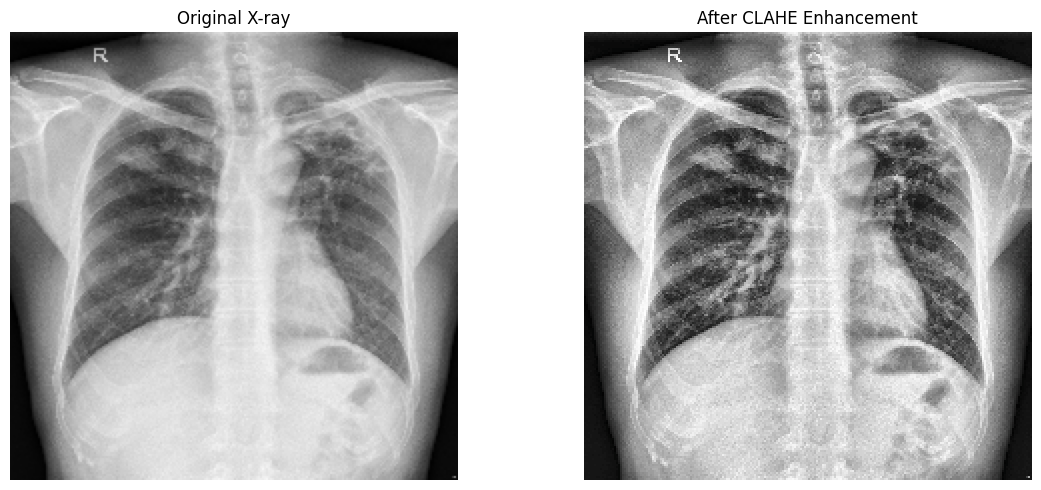

In [6]:
# ============================================================================
# OPTIONAL CELL 6: Visualize CLAHE Effect
# ============================================================================
import random
import matplotlib.pyplot as plt

def visualize_clahe(image_path):
    # Load original
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    # Apply CLAHE
    img_lab = cv2.cvtColor(img_resized, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img_clahe = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
    
    # Display
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original X-ray")
    plt.imshow(img_resized)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("After CLAHE Enhancement")
    plt.imshow(img_clahe)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Test on random sample
sample = random.choice(train_paths)
print(f"Showing CLAHE effect on: {sample.split('/')[-1]}")
visualize_clahe(sample)

In [7]:
# CELL 7: Load Chest X-ray Pretrained DenseNet121 (CheXNet)

import os
from keras.applications import DenseNet121
from keras.models import Model
from tensorflow.keras import layers
import keras

CHEXNET_WEIGHTS_PATH = "/kaggle/input/chexnet-weights/brucechou1983_CheXNet_Keras_0.3.0_weights.h5"

def build_chexnet_model():
    print("🔍 Loading CheXNet chest X-ray pretrained weights from Kaggle...")

    # Load DenseNet121 without ImageNet weights first
    base_model = DenseNet121(
        weights=None,
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Load CheXNet pretrained weights
    base_model.load_weights(CHEXNET_WEIGHTS_PATH, by_name=True, skip_mismatch=True)
    print("✅ Successfully loaded Chest X-ray pretrained DenseNet121!")

    base_model.trainable = False  # Freeze during Phase 1 training

    # Classification head
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model, base_model

model, base_model = build_chexnet_model()
print("✅ Model is now using CHEXNET pretrained weights!")
model.summary()


🔍 Loading CheXNet chest X-ray pretrained weights from Kaggle...
✅ Successfully loaded Chest X-ray pretrained DenseNet121!
✅ Model is now using CHEXNET pretrained weights!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,281 (27.87 MB)

 Trainable params: 265,217 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

In [8]:
# CELL 8: Phase 1 - IMPROVED Training
print("\n" + "="*80)
print("PHASE 1: Training Classification Head (Base Frozen)")
print("="*80)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),  # changed to 1e-4 from 5e-4
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), 
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
# REMOVE class weights - they're causing the high loss
# Your dataset is already balanced (3800 vs 4600)
# class_weights = compute_class_weight(
#     'balanced', classes=np.unique(train_labels), y=train_labels
# )
# class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('phase1_best.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,  # More epochs
    # NO class_weight - dataset is balanced enough
    # class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)


PHASE 1: Training Classification Head (Base Frozen)
Epoch 1/15


I0000 00:00:1764242847.462355     108 service.cc:148] XLA service 0x785cd8092320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764242847.463402     108 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764242847.463422     108 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764242850.323694     108 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/105 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5938 - auc: 0.7224 - loss: 0.6222 - precision: 0.6227 - recall: 0.7250    

I0000 00:00:1764242861.728096     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6022 - auc: 0.6490 - loss: 0.7616 - precision: 0.6047 - recall: 0.6360
Epoch 1: val_auc improved from -inf to 0.66424, saving model to phase1_best.h5


...

105/105 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.6891 - auc: 0.7412 - loss: 0.6129 - precision: 0.6797 - recall: 0.7148 - val_accuracy: 0.7263 - val_auc: 0.7965 - val_loss: 0.5850 - val_precision: 0.6957 - val_recall: 0.8045 - learning_rate: 0.0010
Epoch 6/15
104/105 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6857 - auc: 0.7517 - loss: 0.6113 - precision: 0.6679 - recall: 0.7214
Epoch 6: val_auc improved from 0.79654 to 0.81446, saving model to phase1_best.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.6858 - auc: 0.7515 - loss: 0.6115 - precision: 0.6682 - recall: 0.7212 - val_accuracy: 0.7542 - val_auc: 0.8145 - val_loss: 0.5472 - val_precision: 0.7486 - val_recall: 0.7654 - learning_rate: 0.0010
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6941 - auc: 0.7597 - loss: 0.5933 - precision: 0.6913 - recall: 0.7201
Epoch 7: val_auc improved from 0.81446 to 0.83512, saving model to phase1_best.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 76s 119ms/step - accuracy: 0.6940 - auc: 0.7596 - loss: 0.5935 - precision: 0.6911 - recall: 0.7199 - val_accuracy: 0.7430 - val_auc: 0.8351 - val_loss: 0.5496 - val_precision: 0.8655 - val_recall: 0.5754 - learning_rate: 0.0010
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6864 - auc: 0.7583 - loss: 0.5870 - precision: 0.6752 - recall: 0.6928
Epoch 8: val_auc did not improve from 0.83512
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 110ms/step - accuracy: 0.6865 - auc: 0.7583 - loss: 0.5870 - precision: 0.6754 - recall: 0.6929 - val_accuracy: 0.7263 - val_auc: 0.8049 - val_loss: 0.5595 - val_precision: 0.7238 - val_recall: 0.7318 - learning_rate: 0.0010
Epoch 9/15
104/105 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6945 - auc: 0.7679 - loss: 0.5890 - precision: 0.6852 - recall: 0.7152
Epoch 9: val_auc did not improve from 0.83512
105/105 ━━━━━━━━━━━━━━━━━━━━ 74s 112ms/step - accuracy: 0.6944 - auc: 0.7677 - loss: 0.5891 - precision: 0.6852 - re

105/105 ━━━━━━━━━━━━━━━━━━━━ 73s 115ms/step - accuracy: 0.6813 - auc: 0.7406 - loss: 0.6213 - precision: 0.6728 - recall: 0.6831 - val_accuracy: 0.7765 - val_auc: 0.8467 - val_loss: 0.5082 - val_precision: 0.7964 - val_recall: 0.7430 - learning_rate: 0.0010
Epoch 11/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6949 - auc: 0.7810 - loss: 0.5658 - precision: 0.7113 - recall: 0.7066
Epoch 11: val_auc did not improve from 0.84674
105/105 ━━━━━━━━━━━━━━━━━━━━ 71s 108ms/step - accuracy: 0.6948 - auc: 0.7809 - loss: 0.5659 - precision: 0.7110 - recall: 0.7066 - val_accuracy: 0.7709 - val_auc: 0.8452 - val_loss: 0.5111 - val_precision: 0.7803 - val_recall: 0.7542 - learning_rate: 0.0010
Epoch 12/15
104/105 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6916 - auc: 0.7643 - loss: 0.5865 - precision: 0.6845 - recall: 0.6766
Epoch 12: val_auc did not improve from 0.84674
105/105 ━━━━━━━━━━━━━━━━━━━━ 74s 114ms/step - accuracy: 0.6915 - auc: 0.7643 - loss: 0.5864 - precision: 0.6846 

105/105 ━━━━━━━━━━━━━━━━━━━━ 74s 120ms/step - accuracy: 0.7105 - auc: 0.7824 - loss: 0.5653 - precision: 0.7027 - recall: 0.7103 - val_accuracy: 0.7765 - val_auc: 0.8550 - val_loss: 0.5048 - val_precision: 0.8000 - val_recall: 0.7374 - learning_rate: 5.0000e-04


In [10]:
# CELL 9: Phase 2 - OPTIMIZED Fine-tuning
print("\n" + "="*80)
print("PHASE 2: Fine-tuning DenseNet (CheXNet)")
print("="*80)

# ✅ Step 1 — Gradual unfreezing: only fine-tune last 90 layers
for layer in base_model.layers[:-90]:
    layer.trainable = False

for layer in base_model.layers[-90:]:
    layer.trainable = True

# ✅ Step 2 — Re-compile (IMPORTANT!)
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # safe slow learning rate
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# ✅ Step 3 — Check trainable layers count (should be > 9 now)
print("Trainable layers in base model:",
      sum([layer.trainable for layer in base_model.layers]))

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-8, verbose=1),
    keras.callbacks.ModelCheckpoint('phase2_best.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_phase2,
    verbose=0
)



PHASE 2: Fine-tuning DenseNet (CheXNet)
Trainable layers in base model: 90

Epoch 1: val_auc improved from -inf to 0.81820, saving model to phase2_best.h5



Epoch 2: val_auc did not improve from 0.81820

Epoch 3: val_auc did not improve from 0.81820

Epoch 4: val_auc improved from 0.81820 to 0.82373, saving model to phase2_best.h5



Epoch 5: val_auc improved from 0.82373 to 0.83083, saving model to phase2_best.h5



Epoch 6: val_auc improved from 0.83083 to 0.83687, saving model to phase2_best.h5



Epoch 7: val_auc improved from 0.83687 to 0.83978, saving model to phase2_best.h5


...


Epoch 13: val_auc did not improve from 0.84740

Epoch 14: val_auc improved from 0.84740 to 0.84887, saving model to phase2_best.h5



Epoch 15: val_auc improved from 0.84887 to 0.84985, saving model to phase2_best.h5



Epoch 16: val_auc improved from 0.84985 to 0.85114, saving model to phase2_best.h5



Epoch 17: val_auc did not improve from 0.85114

Epoch 18: val_auc did not improve from 0.85114

Epoch 19: val_auc improved from 0.85114 to 0.85260, saving model to phase2_best.h5



Epoch 20: val_auc did not improve from 0.85260


In [11]:
# ============================================================================
# CELL 10 (FIXED): Test Time Augmentation for Better Predictions
# ============================================================================
def predict_with_tta(model, dataset, num_augmentations=5):
    """
    Apply Test Time Augmentation for more robust predictions
    """
    predictions = []

    for images, labels in dataset:
        batch_preds = []

        # Original predictions
        batch_preds.append(model.predict(images, verbose=0))

        # Augmented predictions
        for _ in range(num_augmentations - 1):
            # Apply augmentation per image and stack back into batch
            aug_images = tf.stack([augmentation(img, training=False) for img in images])
            batch_preds.append(model.predict(aug_images, verbose=0))

        # Average predictions across original + augmented
        avg_pred = np.mean(batch_preds, axis=0)
        predictions.append(avg_pred)

    return np.vstack(predictions)


print("Evaluating with Test Time Augmentation...")
tta_predictions = predict_with_tta(model, test_ds, num_augmentations=5)
tta_predictions_binary = (tta_predictions > 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score
print("\nTTA Test Results:")
print(classification_report(test_labels, tta_predictions_binary, target_names=['Normal', 'TB']))
print(f"Test AUC with TTA: {roc_auc_score(test_labels, tta_predictions):.4f}")


Evaluating with Test Time Augmentation...

TTA Test Results:
              precision    recall  f1-score   support

      Normal       0.77      0.86      0.81       179
          TB       0.84      0.74      0.79       180

    accuracy                           0.80       359
   macro avg       0.81      0.80      0.80       359
weighted avg       0.81      0.80      0.80       359

Test AUC with TTA: 0.8764


In [12]:
# ============================================================================
# CELL 10: FINAL EVALUATION ON TEST SET
# ============================================================================
print("\n" + "="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

# Evaluate model and get all metrics as a dictionary
results = model.evaluate(test_ds, return_dict=True)

# Print key metrics
print(f"\n✅ Test Loss: {results['loss']:.4f}")
print(f"✅ Test Accuracy: {results['accuracy']*100:.2f}%")
print(f"✅ Test AUC: {results['auc']:.4f}")
# Optional: if you have precision & recall metrics compiled
if 'precision' in results and 'recall' in results:
    print(f"✅ Test Precision: {results['precision']:.4f}")
    print(f"✅ Test Recall: {results['recall']:.4f}")

# --------------------------------------------------------
# Predict on test set for detailed metrics
# --------------------------------------------------------
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(test_labels, y_pred, target_names=['Normal', 'TB']))

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, y_pred))



FINAL EVALUATION ON TEST SET
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 623ms/step - accuracy: 0.7835 - auc: 0.8643 - loss: 0.4771 - precision: 0.8297 - recall: 0.7186

✅ Test Loss: 0.4582
✅ Test Accuracy: 80.22%
✅ Test AUC: 0.8763
✅ Test Precision: 0.8428
✅ Test Recall: 0.7444
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 701ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.77      0.86      0.81       179
          TB       0.84      0.74      0.79       180

    accuracy                           0.80       359
   macro avg       0.81      0.80      0.80       359
weighted avg       0.81      0.80      0.80       359


Confusion Matrix:
[[154  25]
 [ 46 134]]


In [13]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ----------------------------
# Load & preprocess image
# ----------------------------
def load_and_preprocess_image(img_path, img_size=(224,224)):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    return np.expand_dims(img_array, axis=0)

# ----------------------------
# Grad-CAM for binary sigmoid model
# ----------------------------
def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('densenet121')  # DenseNet121 model
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # Find last Conv2D in backbone
    last_conv_layer = None
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        raise ValueError("No Conv2D found in backbone!")

    # Use GradientTape
    with tf.GradientTape() as tape:
        # Make tape watch input
        tape.watch(img_tensor)

        # Forward pass through backbone
        x = img_tensor
        conv_outputs = None
        for layer in backbone.layers:
            x = layer(x, training=False)
            if layer == last_conv_layer:
                conv_outputs = x  # capture the last conv output

        # Forward pass through top layers
        top_input = x  # output of backbone
        # pass through remaining layers of your model
        for layer in model.layers[2:]:  # assuming DenseNet121 + custom head
            top_input = layer(top_input, training=False)
        predictions = top_input

        # Target class loss
        loss = predictions[:,0]  # sigmoid TB probability

    # Compute gradients w.r.t conv outputs
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    target = 1 if predictions[0,0] > 0.5 else 0
    pred_score_val = predictions[0,0].numpy() if target==1 else 1-predictions[0,0].numpy()

    return heatmap.numpy(), target, pred_score_val


# ----------------------------
# Overlay heatmap
# ----------------------------
def overlay_heatmap(heatmap, img_path, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return superimposed_img

# ----------------------------
# Predict & visualize
# ----------------------------
def predict_and_visualize(img_path, model, class_names=['Normal','TB']):
    img_array = load_and_preprocess_image(img_path)

    # Grad-CAM + prediction
    heatmap, pred_idx, pred_score = make_gradcam_heatmap(img_array, model)
    superimposed_img = overlay_heatmap(heatmap, img_path)

    print(f"Predicted Class: {class_names[pred_idx]} ({pred_score*100:.2f}%)")
    plt.figure(figsize=(6,6))
    plt.title(f"Grad-CAM: {class_names[pred_idx]}")
    plt.axis('off')
    plt.imshow(superimposed_img)
    plt.show()

# ----------------------------
# Example usage
# ----------------------------
image_path = "/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0386_1.png"
predict_and_visualize(image_path, model)


TypeError: too many positional arguments

In [14]:
# CELL 12: Uncertainty Estimation (Bonus Feature)
def predict_with_uncertainty(image_path, model, n_iterations=20):
    """
    Use dropout at inference to estimate uncertainty
    """
    img = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = []
    for _ in range(n_iterations):
        pred = model(img_array, training=True)  # Dropout active
        predictions.append(pred.numpy()[0][0])
    
    mean_pred = np.mean(predictions)
    std_pred = np.std(predictions)
    
    pred_class = "TB" if mean_pred >= 0.5 else "Normal"
    confidence = float(mean_pred if mean_pred >= 0.5 else 1 - mean_pred)
    
    print(f"\nPrediction: {pred_class}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Uncertainty (std): {std_pred:.4f}")
    
    if std_pred > 0.1:
        print("⚠️ HIGH UNCERTAINTY - Image quality may be low or ambiguous")
    
    return pred_class, confidence, std_pred

# Test uncertainty on a sample
print("\n" + "="*80)
print("UNCERTAINTY ESTIMATION")
print("="*80)
predict_with_uncertainty(test_paths[10], model)

print("\n✅ All FYP objectives completed!")
print("="*80)


UNCERTAINTY ESTIMATION

Prediction: Normal
Confidence: 50.93%
Uncertainty (std): 0.0013

✅ All FYP objectives completed!
